# Creating a bar plot of solar heating terms



In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import warnings
import itertools

import numpy as np
import pandas as pd
import xarray as xr
import pint_xarray
import cf_xarray as cfxr
from cf_xarray.units import units

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib.ticker import MaxNLocator

import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator, FuncFormatter
from matplotlib.patches import FancyBboxPatch, Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import seaborn as sns
import cmocean

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as ctk
import cartopy.mpl.patch as cpatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import shapely
import geopandas as gpd
import salem
import regionmask

import intake
import intake_esm
import dask_jobqueue
import distributed
from distributed import Client
from ncar_jobqueue import NCARCluster

import xeofs
from xeofs.models import MCA, MCARotator
import pop_tools
from tqdm import tqdm
import pandas as pd


# --- Cartopy feature ---
land_50m = cfeature.NaturalEarthFeature(
    'physical', 'land', '50m',
    edgecolor='face',
    facecolor=cfeature.COLORS['land']
)

# --- xarray options ---
xr.set_options(keep_attrs=True)

%matplotlib inline
%watermark -iv


/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2241/660847670.py:35: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


cf_xarray    : 0.8.2
regionmask   : 0.12.1
pint_xarray  : 0.3
matplotlib   : 3.7.1
xarray       : 2023.6.0
shapely      : 2.0.1
pandas       : 2.0.2
pop_tools    : 2023.3.0
dask_jobqueue: 0.8.2
cartopy      : 0.21.1
xeofs        : 1.0.3
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
cmocean      : 3.0.3
salem        : 0.3.10
intake_esm   : 2023.6.14
intake       : 0.7.0
geopandas    : 0.13.2
numpy        : 1.23.5
seaborn      : 0.12.2
distributed  : 2023.6.0



In [4]:

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

Writing down the equation for change in solar insolation

\begin{equation}
    Q_{\downarrow}^\prime = \overline{Q_{sw}} \bigg(\underbrace{C^\prime (\alpha_w  -  \overline{\alpha_{i}})}_\text{I} - \underbrace{\overline{C}\alpha_{i}^\prime}_\text{II}  - \underbrace{(C^\prime \alpha_{i}^\prime)^\prime}_\text{III}\bigg)+  Q_{sw}^\prime \bigg(\underbrace{ 1- \alpha_w}_\text{IV} +  \underbrace{\overline{C} (\alpha_w - \overline{\alpha_i})}_\text{V}\bigg)  + \underbrace{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}_\text{VI} - \underbrace{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}_\text{VII} - \underbrace{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}_\text{VIII}.
\end{equation}


Loading all the terms in the solar heating equation

In [5]:
ds_LENS2 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_66N_1920_1950_LENS2.nc')
ds_LENS1 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_66N_LENS1.nc')
ds_heating_obs = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_obs.nc')

Loading the shortwave radiation decomposition terms

In [6]:
ds_q_prime_LENS2 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_1920_1950_LENS2.nc')
ds_q_prime_LENS1 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_LENS1.nc')
ds_q_prime_obs = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_obs.nc')

### Computing from 1982-2002 mean

In [7]:
# --- Step 0: Compute 1982–2002 baseline climatology ---
clim_LENS2 = ds_LENS2.sel(time=slice("1982", "2002")).mean("time")
clim_LENS1 = ds_LENS1.sel(time=slice("1982", "2002")).mean("time")

clim_qp_LENS2 = ds_q_prime_LENS2.sel(time=slice("1982", "2002")).mean("time")
clim_qp_LENS1 = ds_q_prime_LENS1.sel(time=slice("1982", "2002")).mean("time")

# --- Convert full datasets into anomalies w.r.t 1982–2002 ---
ds_new_LENS2_anom = ds_LENS2 - clim_LENS2
ds_new_LENS1_anom = ds_LENS1 - clim_LENS1

ds_qprime_LENS2_anom = ds_q_prime_LENS2 - clim_qp_LENS2
ds_qprime_LENS1_anom = ds_q_prime_LENS1 - clim_qp_LENS1

################
sel_mjja_LENS2 = (ds_new_LENS2_anom['time.month'] >= 5) & (ds_new_LENS2_anom['time.month'] <= 8)
sel_mjja_LENS1 = (ds_new_LENS1_anom['time.month'] >= 5) & (ds_new_LENS1_anom['time.month'] <= 8)

ds_mjja_LENS2 = ds_new_LENS2_anom.sel(time=sel_mjja_LENS2)
ds_mjja_LENS1 = ds_new_LENS1_anom.sel(time=sel_mjja_LENS1)

ds_qprime_mjja_LENS2 = ds_qprime_LENS2_anom.sel(time=sel_mjja_LENS2)
ds_qprime_mjja_LENS1 = ds_qprime_LENS1_anom.sel(time=sel_mjja_LENS1)

##################

ds_mjja_LENS2 = ds_mjja_LENS2.sel(time=slice("1982-01", "2100-12"))
ds_mjja_LENS1 = ds_mjja_LENS1.sel(time=slice("1982-01", "2100-12"))

ds_qprime_mjja_LENS2 = ds_qprime_mjja_LENS2.sel(time=slice("1982-01", "2100-12"))
ds_qprime_mjja_LENS1 = ds_qprime_mjja_LENS1.sel(time=slice("1982-01", "2100-12"))


######################
def get_seconds_per_month(time):
    return xr.DataArray(
        [pd.Period(f"{t.dt.year.values}-{t.dt.month.values}").days_in_month * 24 * 3600
         for t in time],
        coords={"time": time},
        dims="time"
    )

seconds_per_month_LENS2 = get_seconds_per_month(ds_mjja_LENS2['time'])
seconds_per_month_LENS1 = get_seconds_per_month(ds_mjja_LENS1['time'])

#######################

ds_accum_month_LENS2 = ds_mjja_LENS2 * seconds_per_month_LENS2
ds_accum_month_LENS1 = ds_mjja_LENS1 * seconds_per_month_LENS1

ds_qprime_accum_month_LENS2 = ds_qprime_mjja_LENS2 * seconds_per_month_LENS2
ds_qprime_accum_month_LENS1 = ds_qprime_mjja_LENS1 * seconds_per_month_LENS1


#######################

ds_accum_year_LENS2 = ds_accum_month_LENS2.groupby("time.year").sum()
ds_accum_year_LENS1 = ds_accum_month_LENS1.groupby("time.year").sum()

ds_qprime_accum_year_LENS2 = ds_qprime_accum_month_LENS2.groupby("time.year").sum()
ds_qprime_accum_year_LENS1 = ds_qprime_accum_month_LENS1.groupby("time.year").sum()

### Same for obs

In [8]:
################
sel_mjja_obs = (ds_heating_obs['time.month'] >= 5) & (ds_heating_obs['time.month'] <= 8)

ds_mjja_obs = ds_heating_obs.sel(time=sel_mjja_obs)

ds_qprime_mjja_obs = ds_q_prime_obs.sel(time=sel_mjja_obs)


######################
def get_seconds_per_month(time):
    return xr.DataArray(
        [pd.Period(f"{t.dt.year.values}-{t.dt.month.values}").days_in_month * 24 * 3600
         for t in time],
        coords={"time": time},
        dims="time"
    )

seconds_per_month_obs = get_seconds_per_month(ds_mjja_obs['time'])

#######################

ds_accum_month_obs = ds_mjja_obs * seconds_per_month_obs

ds_qprime_accum_month_obs = ds_qprime_mjja_obs * seconds_per_month_obs


#######################

ds_accum_year_obs = ds_accum_month_obs.groupby("time.year").sum()

ds_qprime_accum_year_obs = ds_qprime_accum_month_obs.groupby("time.year").sum()

### Plotting

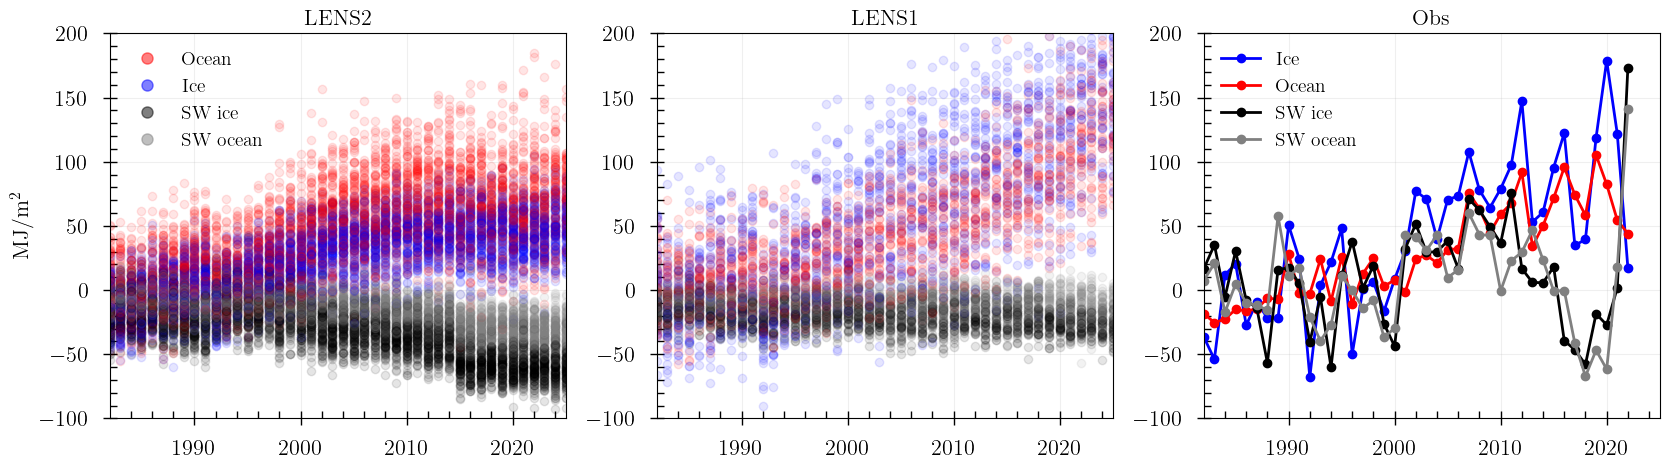

In [29]:
# --- Plot ---
fig, ax = plt.subplots(ncols=3, figsize=(20, 5), sharex=True)

ax = ax.flatten()


for ens in range(100):
    ax[0].plot(ds_accum_year_LENS2['year'], 1e-6 * ds_accum_year_LENS2['II'].sel(ensemble=ens), 'o', c='b', alpha=0.1,lw=1)
    ax[0].plot(ds_accum_year_LENS2['year'], 1e-6 * ds_accum_year_LENS2['I'].sel(ensemble=ens), 'o', c='r', alpha=0.1,lw=1)
    ax[0].plot(ds_accum_year_LENS2['year'], 1e-6 * ds_qprime_accum_year_LENS2['q_prime_ice'].sel(ensemble=ens), 'o', c='k',alpha=0.1, lw=1)
    ax[0].plot(ds_accum_year_LENS2['year'], 1e-6 * ds_qprime_accum_year_LENS2['q_prime_ocn'].sel(ensemble=ens), 'o', c='grey', alpha=0.1,lw=1)

for ens in range(39):
    ax[1].plot(ds_accum_year_LENS1['year'], 1e-6 * ds_accum_year_LENS1['II'].sel(ensemble=ens), 'o', c='b', alpha=0.1,lw=1)
    ax[1].plot(ds_accum_year_LENS1['year'], 1e-6 * ds_accum_year_LENS1['I'].sel(ensemble=ens), 'o', c='r', alpha=0.1,lw=1)
    ax[1].plot(ds_accum_year_LENS1['year'], 1e-6 * ds_qprime_accum_year_LENS1['q_prime_ice'].sel(ensemble=ens), 'o', c='k',alpha=0.1, lw=1)
    ax[1].plot(ds_accum_year_LENS1['year'], 1e-6 * ds_qprime_accum_year_LENS1['q_prime_ocn'].sel(ensemble=ens), 'o', c='grey', alpha=0.1,lw=1)


ax[2].plot(ds_accum_year_obs['year'], 1e-6 * ds_accum_year_obs['II'], '-o', c='b', lw=2, label='Ice')
ax[2].plot(ds_accum_year_obs['year'], 1e-6 * ds_accum_year_obs['I'], '-o', c='r', lw=2, label='Ocean')
ax[2].plot(ds_accum_year_obs['year'], 1e-6 * ds_qprime_accum_year_obs['q_prime_ice'], '-o', c='k', lw=2, label='SW ice')
ax[2].plot(ds_accum_year_obs['year'], 1e-6 * ds_qprime_accum_year_obs['q_prime_ocn'], '-o', c='grey', lw=2, label='SW ocean')

for i in range(3):
    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)
    ax[i].set_xlim(1982, 2025)
    ax[i].set_ylim(-100, 200)
    
ax[2].legend(fontsize=14, frameon=False)
ax[0].set_ylabel(r'MJ/m$^2$', fontsize=16)

ax[0].set_title(r'LENS2', fontsize=16)
ax[1].set_title(r'LENS1', fontsize=16)
ax[2].set_title(r'Obs', fontsize=16)


from matplotlib.lines import Line2D

# Proxy handles for the legend
legend_elements = [
    # Observations
    # Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='k', markersize=8, label='Obs ocean'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='k', markersize=8, label='Obs ice'),
    
    # LENS1
    Line2D([0], [0], marker='o', color='red', lw=0 , markersize=8, alpha=0.5, label=r'Ocean'),
    Line2D([0], [0], marker='o', color='blue', lw=0  , markersize=8, alpha=0.5, label=r'Ice'),
    Line2D([0], [0], marker='o', color='k', lw=0  , markersize=8, alpha=0.5, label=r'SW ice'),
    Line2D([0], [0], marker='o', color='grey', lw=0  , markersize=8, alpha=0.5, label=r'SW ocean'),
    
#     # LENS2
#     Line2D([0], [0], marker='x', color='green', lw=0, markersize=8, alpha=0.3, label='LENS2 ocean'),
#     Line2D([0], [0], marker='x', color='purple', lw=0, markersize=8, alpha=0.3, label='LENS2 ice')
# 
]

ax[0].legend(handles=legend_elements, frameon=False, fontsize=14, loc='upper left')

plt.savefig("../figs/cumulative_heating_with_time_model_obs_comparison.png", dpi=300, bbox_inches="tight")



In [10]:
ds_sia_LENS2 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/sia_monthly.nc')
ds_sia_LENS1 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/sia_monthly_mjja_LENS1.nc')

In [11]:
time_period = ('1982-01', '2100-12')

In [12]:
ds_sia_LENS2 = ds_sia_LENS2.sel(time=slice(*time_period))
ds_sia_LENS1 = ds_sia_LENS1.sel(time=slice(*time_period))

In [13]:
sia_PIP = (ds_sia_LENS2['sia_may'].dropna(dim='time').values +\
           ds_sia_LENS2['sia_jun'].dropna(dim='time').values+\
           ds_sia_LENS2['sia_jul'].dropna(dim='time').values+\
           ds_sia_LENS2['sia_aug'].dropna(dim='time').values)*0.25

In [14]:
time = np.arange("1982", "2101", dtype="datetime64[Y]")

# Infer ensemble size from NumPy arrays
ensemble_size = 100  # Assuming first axis is ensemble

# Create xarray DataArrays
sia_PIP_xr = xr.DataArray(sia_PIP, dims=("ensemble", "time"), coords={"ensemble": np.arange(ensemble_size), "time": time})

# Combine into a dataset
ds_sia_avg = xr.Dataset({
    "sia_PIP": sia_PIP_xr
})

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2241/2011947480.py:7: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  sia_PIP_xr = xr.DataArray(sia_PIP, dims=("ensemble", "time"), coords={"ensemble": np.arange(ensemble_size), "time": time})


In [15]:
sia_PIP_l1 = (ds_sia_LENS1['sia_may'].dropna(dim='time').values+\
              ds_sia_LENS1['sia_jun'].dropna(dim='time').values+\
              ds_sia_LENS1['sia_jul'].dropna(dim='time').values+
              ds_sia_LENS1['sia_aug'].dropna(dim='time').values)*0.25

In [16]:
time = np.arange("1982", "2101", dtype="datetime64[Y]")

# Infer ensemble size from NumPy arrays
ensemble_size = 40  # Assuming first axis is ensemble

# Create xarray DataArrays
sia_PIP_l1_xr = xr.DataArray(sia_PIP_l1, dims=("ensemble", "time"), coords={"ensemble": np.arange(ensemble_size), "time": time})

# Combine into a dataset
ds_sia_avg_l1 = xr.Dataset({
    "sia_PIP": sia_PIP_l1_xr
})

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2241/264068621.py:7: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  sia_PIP_l1_xr = xr.DataArray(sia_PIP_l1, dims=("ensemble", "time"), coords={"ensemble": np.arange(ensemble_size), "time": time})


### Computing sea ice area

In [17]:
ds_nsidc = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/NSIDC_monthly.nc').sel(time=slice('1982-01','2022-12'))
ds_nsidc

<xarray.Dataset>
Dimensions:          (time: 492, y: 448, x: 304)
Coordinates:
    xgrid            (x) float32 ...
    ygrid            (y) float32 ...
    latitude         (y, x) float32 ...
    longitude        (y, x) float32 ...
  * time             (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 ...
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

In [18]:
# assume your dataset is called ds
sic = ds_nsidc['cdr_seaice_conc']

# 1️⃣ Compute grid spacing (in meters)
dx = np.abs(ds_nsidc.xgrid.diff('x').mean().item())
dy = np.abs(ds_nsidc.ygrid.diff('y').mean().item())

print(f"Grid spacing: dx={dx:.1f} m, dy={dy:.1f} m")

# 2️⃣ Compute grid cell area
cell_area = dx * dy  # in m²

# 3️⃣ Convert SIC to fraction and mask invalid values
sic = sic.where((sic >= 0) & (sic <= 1))

# 4️⃣ Compute total ice-covered area (sum over spatial dims)
seaice_area = (sic * cell_area).sum(dim=['y', 'x'])

# 5️⃣ Convert to million km²
seaice_area_mkm2 = (seaice_area / 1e6) / 1e6
seaice_area_mkm2.name = 'seaice_area_million_km2'

seaice_area_mkm2


Grid spacing: dx=25000.0 m, dy=25000.0 m


<xarray.DataArray 'seaice_area_million_km2' (time: 492)>
array([14.357784 , 15.229325 , 15.333651 , 14.696651 , 13.028858 ,
       11.238289 ,  9.086908 ,  7.150245 ,  6.5719113,  8.528151 ,
       10.716951 , 12.802279 , 14.183435 , 15.326203 , 15.390678 ,
       14.31971  , 12.676829 , 11.243634 ,  9.282406 ,  7.1205754,
        6.6951466,  8.461545 , 10.644109 , 12.525851 , 13.794404 ,
       14.62881  , 14.931125 , 14.280511 , 12.724091 , 11.043801 ,
        9.954865 ,  6.786808 ,  6.2575717,  7.822828 , 10.103151 ,
       12.258008 , 13.999429 , 14.784889 , 15.164168 , 14.631366 ,
       13.151634 , 10.951542 ,  8.588674 ,  6.6229486,  6.2051263,
        7.835447 , 10.163872 , 12.225819 , 14.056534 , 15.056565 ,
       15.268181 , 14.174503 , 12.57776  , 10.956604 ,  8.958849 ,
        7.022235 ,  6.7323804,  8.609281 , 10.64711  , 12.635411 ,
       14.243187 , 15.411266 , 15.13396  , 14.475284 , 12.881741 ,
       11.279954 ,  9.006187 ,  6.6150823,  6.64691  ,  8.392435 ,
       10.470487 , 11.778221 , 14.444319 , 15.034075 , 15.353824 ,
       14.286598 , 12.500557 , 10.617688 ,  8.525428 ,  6.8211584,
        6.6551237,  8.470317 , 10.576711 , 12.859892 , 14.24518  ,
       14.767537 , 14.577373 , 13.383322 , 12.124146 , 10.882982 ,
        8.692572 ,  6.7153344,  6.1783366,  8.134963 , 10.34716  ,
       12.629307 , 14.080481 , 14.967041 , 15.137852 , 13.62685  ,
...
       11.472181 , 12.787379 , 13.631136 , 13.493158 , 12.956454 ,
       11.400098 ,  9.428624 ,  6.8140483,  4.499565 ,  3.9649858,
        6.2143617,  9.039297 , 11.167655 , 12.622088 , 13.395861 ,
       13.583724 , 12.647325 , 10.794578 ,  8.936532 ,  6.5875425,
        4.2216935,  3.7469013,  5.3604803,  7.8577933, 10.503803 ,
       12.303619 , 13.226005 , 13.390227 , 12.779701 , 11.505532 ,
        9.131834 ,  6.627928 ,  4.532724 ,  4.1587024,  6.0436296,
        8.633661 , 10.847418 , 12.284145 , 13.130875 , 13.471332 ,
       12.76528  , 11.190184 ,  9.422541 ,  6.8292394,  4.5902085,
        4.080977 ,  5.451518 ,  9.022278 , 11.007921 , 12.768998 ,
       13.593025 , 13.693331 , 12.422421 , 11.021101 ,  9.017189 ,
        6.1533403,  4.07236  ,  3.7347882,  5.068606 ,  8.495116 ,
       11.05453  , 12.835124 , 13.819161 , 13.811882 , 12.636393 ,
       11.15012  ,  9.106302 ,  6.0695515,  3.9834945,  3.394357 ,
        4.682589 ,  8.144901 , 10.812484 , 12.603094 , 13.551784 ,
       13.782662 , 12.783917 , 11.461223 ,  9.196239 ,  6.522716 ,
        4.6425867,  4.186038 ,  6.098336 ,  9.022788 , 11.255107 ,
       13.012026 , 13.742589 , 13.650334 , 13.041491 , 11.697157 ,
        9.289047 ,  6.9810104,  4.8651414,  4.1826167,  5.924461 ,
        8.944555 , 10.983413 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
Attributes:
    long_name:            NOAA/NSIDC Climate Data Record of Passive Microwave...
    standard_name:        sea_ice_area_fraction
    units:                1
    flag_values:          [251 252 253 254 255]
    flag_meanings:        pole_hole lakes coastal land_mask missing_data
    datum:                +ellps=urn:ogc:def:crs:EPSG::4326
    grid_mapping:         projection
    reference:            https://nsidc.org/data/g02202/versions/4/
    ancillary_variables:  stdev_of_cdr_seaice_conc qa_of_cdr_seaice_conc
    valid_range:          [  0 100]
    cell_methods:         tdim: mean

In [19]:
# --- 4. Remove negative or unrealistic values ---
# Example: below 0 or above 20 million km² (Arctic typical range ~0–15)
seaice_area_mkm2 = seaice_area_mkm2.where(
    (seaice_area_mkm2 >= 2) & (seaice_area_mkm2 <= 20)
)

# --- 5. (Optional) Remove statistical outliers ---
# Compute z-scores to remove isolated spikes
z = (seaice_area_mkm2 - seaice_area_mkm2.mean()) / seaice_area_mkm2.std()
seaice_area_mkm2 = seaice_area_mkm2.where(np.abs(z) < 3)



In [20]:
# --- Select only May–August (MJJA) ---
mjja_sia = seaice_area_mkm2.sel(time=seaice_area_mkm2['time'].dt.month.isin([5, 6, 7, 8]))

# --- Compute MJJA mean per year ---
mjja_mean_sia = mjja_sia.resample(time="1Y").mean()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


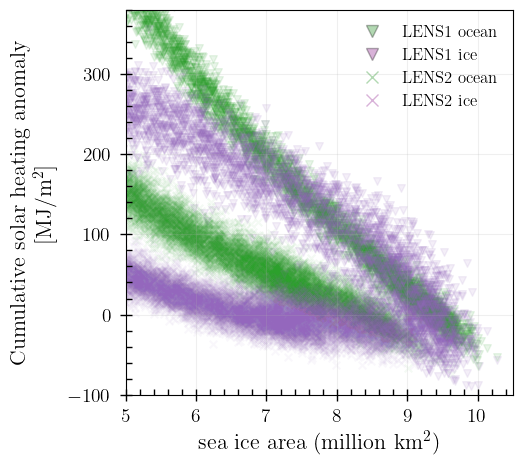

In [32]:
fig, ax = plt.subplots(figsize=(5,5))

# --- Prepare variables ---
variables = [list(ds_mjja_LENS1.data_vars)[0],
             list(ds_mjja_LENS1.data_vars)[1]]

# Colors by physical variable (ocean vs ice)
var_colors = {
    "ocn": "tab:green",
    "ice": "tab:purple"
}

# --- Plot cumulative data vs sea ice area ---
for idx, var in enumerate(variables):

    # Pick color: 0 = ocean, 1 = ice
    color_var = var_colors["ocn"] if idx == 0 else var_colors["ice"]

    # ====== LENS1 ======
    data_LENS1 = ds_accum_year_LENS1[var].copy()
    q_var = ds_qprime_accum_year_LENS1['q_prime_ocn'] if idx == 0 else ds_qprime_accum_year_LENS1['q_prime_ice']
    data_LENS1, q_var = xr.align(data_LENS1, q_var, join="inner")
    data_LENS1 = data_LENS1 + q_var

    for ens in range(39):
        sia_vals_l1 = ds_sia_avg_l1['sia_PIP'].sel(ensemble=ens).values
        ax.scatter(
            sia_vals_l1 * 1e-20,
            data_LENS1.sel(ensemble=ens) / 1e6,
            color=color_var,
            alpha=0.1,
            s=30, 
            marker='v'
        )

    # ====== LENS2 ======
    data_LENS2 = ds_accum_year_LENS2[var].copy()
    q_var2 = ds_qprime_accum_year_LENS2['q_prime_ocn'] if idx == 0 else ds_qprime_accum_year_LENS2['q_prime_ice']
    data_LENS2, q_var2 = xr.align(data_LENS2, q_var2, join="inner")
    data_LENS2 = data_LENS2 + q_var2

    for ens in data_LENS2.ensemble.values:
        sia_vals_l2 = ds_sia_avg['sia_PIP'].sel(ensemble=ens).values
        ax.scatter(
            sia_vals_l2 * 1e-16,
            data_LENS2.sel(ensemble=ens) / 1e6,
            color=color_var,
            alpha=0.05,
            s=30, 
            marker='x'
        )

# === Observations ===
# Ocean
# ax.scatter(
#     mjja_mean_sia,
#     1e-6 * (ds_accum_year_obs['I'] + ds_qprime_accum_year_obs['q_prime_ocn']),
#     s=20, color=var_colors["ocn"], edgecolors='k', label=r"heating over ocean", zorder=75
# )

# # Ice
# ax.scatter(
#     mjja_mean_sia,
#     1e-6 * (ds_accum_year_obs['II'] + ds_qprime_accum_year_obs['q_prime_ice']),
#     s=20, color=var_colors["ice"], edgecolors='k', label=r"heating over ice", zorder=75
# )

# --- Formatting ---
ax.tick_params(which='both', labelsize=14, direction='inout', width=1, length=8, pad=6)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=4, width=1, color='k')
ax.grid(alpha=0.2)

# Legend shows only variable type
ax.legend(frameon=False, loc='upper right', fontsize=12, ncol=1)

ax.set_ylabel(
    "Cumulative solar heating anomaly\n[MJ/m$^2]$",
    fontsize=16,
    rotation=90,      # vertical
    va='center',      # vertically centered along the axis
    ha='center' ,
    labelpad=25,# horizontal alignment
)

ax.set_xlabel(r'sea ice area (million km$^2$)', fontsize=16)

ax.set_xlim(5,10.5)
ax.set_ylim(-1e2, 3.8e2)

from matplotlib.lines import Line2D

# Proxy handles for the legend
legend_elements = [
    # # Observations
    # Line2D([0], [0], marker='o', color='w', markerfacecolor=var_colors["ocn"], markeredgecolor='k', markersize=8, label='Obs ocean'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor=var_colors["ice"], markeredgecolor='k', markersize=8, label='Obs ice'),
    
    # LENS1
    Line2D([0], [0], marker='v', color='green', lw=0, markeredgecolor='k' , markersize=8, alpha=0.3, label='LENS1 ocean'),
    Line2D([0], [0], marker='v', color='purple', lw=0, markeredgecolor='k', markersize=8, alpha=0.3, label='LENS1 ice'),
    
    # LENS2
    Line2D([0], [0], marker='x', color='green', lw=0, markersize=8, alpha=0.3, label='LENS2 ocean'),
    Line2D([0], [0], marker='x', color='purple', lw=0, markersize=8, alpha=0.3, label='LENS2 ice')
]

ax.legend(handles=legend_elements, frameon=False, fontsize=12, loc='upper right')

plt.savefig("../figs/cumulative_heating_with_sia_model_obs_comparison_no_obs.png", dpi=300, bbox_inches="tight")


### Final figure

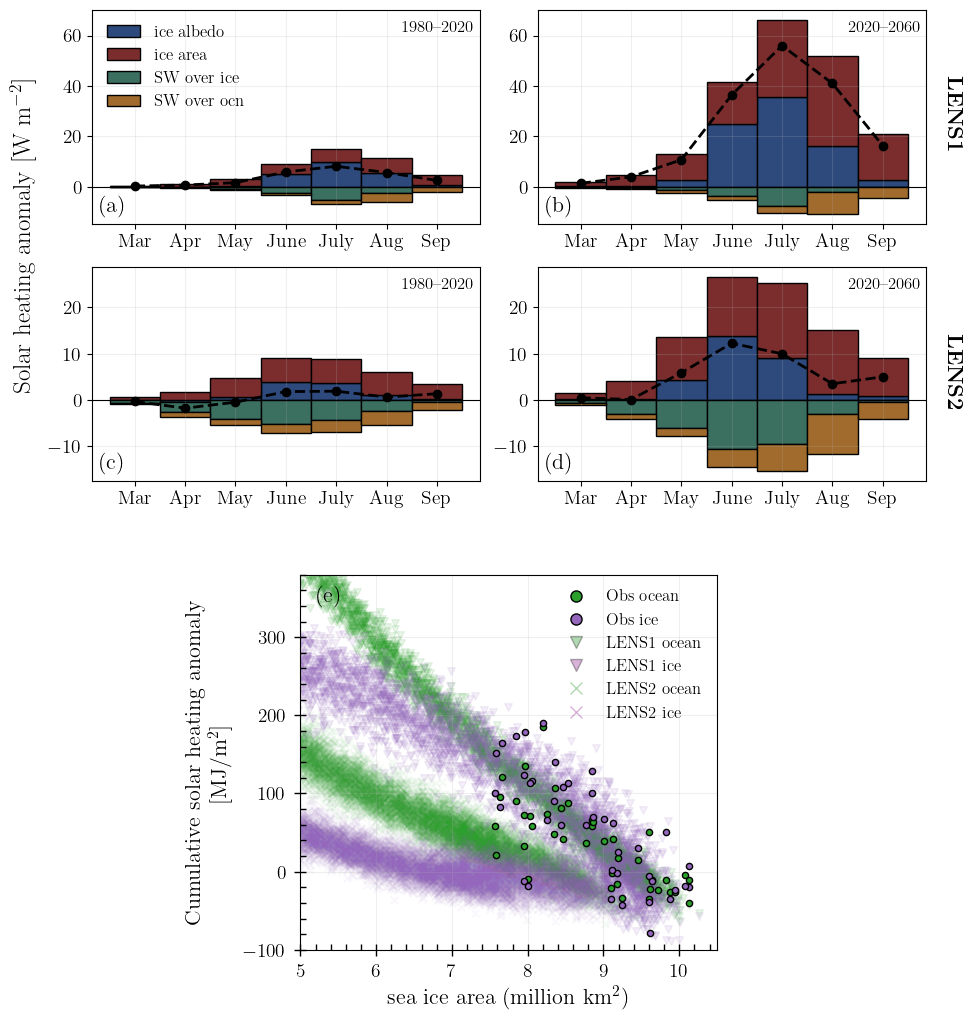

In [22]:
# --- Setup ---
months = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')
months_sel = months[2:9]  # Mar–Sep
sel_idx = np.arange(2, 9)

periods = [
    ('1980-01', '2020-12'),
    ('2020-01', '2060-12')
]

colors_main = {
    "ice albedo": "#2E4A7D",
    "ice area": "#7B2D2D",
}
colors_sw = {
    "SW over ice": "#3B6F5F",
    "SW over ocn": "#A06B2C",
}
colors_all = {**colors_main, **colors_sw}

# --- Create 2x2 grid ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), sharey=False)

# datasets to loop over
datasets = [
    ("LENS1", ds_LENS1, ds_q_prime_LENS1),
    ("LENS2", ds_LENS2, ds_q_prime_LENS2)
]

for row, (label_ds, ds_main, ds_q) in enumerate(datasets):
    for col, time_period in enumerate(periods):
        ax = axes[row, col]

        # --- Compute contributions ---
        ice_albedo = ds_main['II'].sel(time=slice(*time_period)).groupby('time.month').mean(dim=['ensemble', 'time']).values
        ice_area   = ds_main['I'].sel(time=slice(*time_period)).groupby('time.month').mean(dim=['ensemble', 'time']).values
        SW_ice     = ds_q['q_prime_ice'].sel(time=slice(*time_period)).groupby('time.month').mean(dim=['ensemble', 'time']).values
        SW_ocn     = ds_q['q_prime_ocn'].sel(time=slice(*time_period)).groupby('time.month').mean(dim=['ensemble', 'time']).values

        # Select Mar–Sep
        ice_albedo = ice_albedo[sel_idx]
        ice_area   = ice_area[sel_idx]
        SW_ice     = SW_ice[sel_idx]
        SW_ocn     = SW_ocn[sel_idx]

        contributions = {
            "ice albedo": ice_albedo,
            "ice area": ice_area,
            "SW over ice": SW_ice,
            "SW over ocn": SW_ocn
        }

        # --- Stacked bar plot ---
        bottom_pos = np.zeros(len(months_sel))
        bottom_neg = np.zeros(len(months_sel))
        
        for label in ["ice albedo", "ice area", "SW over ice", "SW over ocn"]:
            vals = contributions[label]
            bar_bottom = np.where(vals >= 0, bottom_pos, bottom_neg)
            ax.bar(
                np.arange(len(months_sel)),
                vals,
                width=1.0,
                bottom=bar_bottom,
                label=label,
                color=colors_all[label],
                edgecolor='black'
            )
            bottom_pos += np.where(vals >= 0, vals, 0)
            bottom_neg += np.where(vals < 0, vals, 0)
        
        # --- Total contribution ---
        total_contrib = sum(contributions[label] for label in contributions)
        ax.plot(
            np.arange(len(months_sel)),
            total_contrib,
            color='black',
            linestyle='--',
            linewidth=2,
            marker='o'
        )

        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(np.arange(len(months_sel)))
        ax.set_xticklabels(months_sel, fontsize=14)
        ax.grid(alpha=0.2)
        ax.text(0.8, 0.95, f"{time_period[0][:4]}–{time_period[1][:4]}",
                transform=ax.transAxes, fontsize=12, va='top', ha='left')

        if (row == 0) and (col == 0):
            ax.legend(loc='upper left', frameon=False, fontsize=12)

# --- Match y-limits within each row ---
for row_axes in axes:
    ymin = min(ax.get_ylim()[0] for ax in row_axes)
    ymax = max(ax.get_ylim()[1] for ax in row_axes)
    for ax in row_axes:
        ax.set_ylim(ymin, ymax)

for ax in axes.flat:
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)

plt.tight_layout(rect=[0.09, 0.12, 1, 1])  # leave room for ax5 below

# --- Add shared y-label ---
fig.text(0.08, 0.6, 'Solar heating anomaly [W m$^{-2}$]',
         va='center', ha='center', rotation='vertical', fontsize=18)

# Adjust tick density on second row
for ax in axes[1, :]:
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.subplots_adjust(wspace=0.15, hspace=0.4)

# ======================================================
# Add ax5 below existing 2x2 grid (new row 3, centered)
# ======================================================

# ============================================================
# --- ADD NEW BOTTOM PANEL (ax5) ---
# ============================================================

fig.canvas.draw()  # ensure positions are known

# Find positions of 2×2 block
bottom_2x2 = axes[1, 0].get_position().y0
left_2x2   = axes[0, 0].get_position().x0
right_2x2  = axes[0, 1].get_position().x1
width_2x2  = right_2x2 - left_2x2

# Define new panel height and vertical placement
height_ax5 = 0.75 * width_2x2
bottom_ax5 = bottom_2x2 - 1.25 *  height_ax5  # small gap below 2x2

# Center it horizontally between two columns
ax5 = fig.add_axes([left_2x2 + width_2x2/4, bottom_ax5, width_2x2/2, height_ax5])

# --- Prepare variables ---
variables = [list(ds_mjja_LENS1.data_vars)[0],
             list(ds_mjja_LENS1.data_vars)[1]]

# Colors by physical variable (ocean vs ice)
var_colors = {
    "ocn": "tab:green",
    "ice": "tab:purple"
}

# --- Plot cumulative data vs sea ice area ---
for idx, var in enumerate(variables):

    # Pick color: 0 = ocean, 1 = ice
    color_var = var_colors["ocn"] if idx == 0 else var_colors["ice"]

    # ====== LENS1 ======
    data_LENS1 = ds_accum_year_LENS1[var].copy()
    q_var = ds_qprime_accum_year_LENS1['q_prime_ocn'] if idx == 0 else ds_qprime_accum_year_LENS1['q_prime_ice']
    data_LENS1, q_var = xr.align(data_LENS1, q_var, join="inner")
    data_LENS1 = data_LENS1 + q_var

    for ens in range(39):
        sia_vals_l1 = ds_sia_avg_l1['sia_PIP'].sel(ensemble=ens).values
        ax5.scatter(
            sia_vals_l1 * 1e-20,
            data_LENS1.sel(ensemble=ens) / 1e6,
            color=color_var,
            alpha=0.1,
            s=30, 
            marker='v'
        )

    # ====== LENS2 ======
    data_LENS2 = ds_accum_year_LENS2[var].copy()
    q_var2 = ds_qprime_accum_year_LENS2['q_prime_ocn'] if idx == 0 else ds_qprime_accum_year_LENS2['q_prime_ice']
    data_LENS2, q_var2 = xr.align(data_LENS2, q_var2, join="inner")
    data_LENS2 = data_LENS2 + q_var2

    for ens in data_LENS2.ensemble.values:
        sia_vals_l2 = ds_sia_avg['sia_PIP'].sel(ensemble=ens).values
        ax5.scatter(
            sia_vals_l2 * 1e-16,
            data_LENS2.sel(ensemble=ens) / 1e6,
            color=color_var,
            alpha=0.05,
            s=30, 
            marker='x'
        )

# === Observations ===
# Ocean
ax5.scatter(
    mjja_mean_sia,
    1e-6 * (ds_accum_year_obs['I'] + ds_qprime_accum_year_obs['q_prime_ocn']),
    s=20, color=var_colors["ocn"], edgecolors='k', label=r"heating over ocean", zorder=75
)

# Ice
ax5.scatter(
    mjja_mean_sia,
    1e-6 * (ds_accum_year_obs['II'] + ds_qprime_accum_year_obs['q_prime_ice']),
    s=20, color=var_colors["ice"], edgecolors='k', label=r"heating over ice", zorder=75
)

# --- Formatting ---
ax5.tick_params(which='both', labelsize=14, direction='inout', width=1, length=8, pad=6)
ax5.xaxis.set_minor_locator(AutoMinorLocator())
ax5.yaxis.set_minor_locator(AutoMinorLocator())
ax5.tick_params(which='minor', direction='in', length=4, width=1, color='k')
ax5.grid(alpha=0.2)

# Legend shows only variable type
ax5.legend(frameon=False, loc='upper right', fontsize=12, ncol=1)

ax5.set_ylabel(r'MJ/m$^2$', fontsize=16)
ax5.set_xlabel(r'sea ice area (million km$^2$)', fontsize=16)

ax5.set_xlim(5,10.5)
ax5.set_ylim(-1e2, 3.8e2)

from matplotlib.lines import Line2D

# Proxy handles for the legend
legend_elements = [
    # Observations
    Line2D([0], [0], marker='o', color='w', markerfacecolor=var_colors["ocn"], markeredgecolor='k', markersize=8, label='Obs ocean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=var_colors["ice"], markeredgecolor='k', markersize=8, label='Obs ice'),
    
    # LENS1
    Line2D([0], [0], marker='v', color='green', lw=0, markeredgecolor='k' , markersize=8, alpha=0.3, label='LENS1 ocean'),
    Line2D([0], [0], marker='v', color='purple', lw=0, markeredgecolor='k', markersize=8, alpha=0.3, label='LENS1 ice'),
    
    # LENS2
    Line2D([0], [0], marker='x', color='green', lw=0, markersize=8, alpha=0.3, label='LENS2 ocean'),
    Line2D([0], [0], marker='x', color='purple', lw=0, markersize=8, alpha=0.3, label='LENS2 ice')
]

ax5.legend(handles=legend_elements, frameon=False, fontsize=12, loc='upper right')


ax5.set_ylabel(
    "Cumulative solar heating anomaly\n[MJ/m$^2]$",
    fontsize=16,
    rotation=90,      # vertical
    va='center',      # vertically centered along the axis
    ha='center' ,
    labelpad=25,# horizontal alignment
)

# --- Final layout adjustment ---
plt.subplots_adjust(wspace=0.15, hspace=0.2)


# ============================================================
# --- Add subplot panel labels (a–e)
# ============================================================

# Flatten the 2×2 axes
axes_flat = axes.flatten()
all_axes = list(axes_flat) + [ax5]

panel_labels = ['a', 'b', 'c', 'd', 'e']

for i, (ax, label) in enumerate(zip(all_axes, panel_labels)):
    if label != 'e':
        # Panels a–d: bottom-left
        ax.text(
            0.02, 0.03,
            f'({label})',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='bottom',
            ha='left'
        )
    else:
        # Panel e (ax5): custom position — example top-left
        ax.text(
            0.04, 0.97,
            f'({label})',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='left'
        )

# Add right-side LENS labels
fig.text(
    1.02,  # near the right edge
    0.8,  # y position for top row (LENS1)
    r"\textbf{LENS1}",
    fontsize=16,
    fontweight='bold',
    color='black',
    ha='right',
    va='center',
    rotation=270
)

fig.text(
    1.02,  # near the right edge
    0.37,  # y position for bottom row (LENS2)
    r"\textbf{LENS2}",
    fontsize=16,
    fontweight='bold',
    color='black',
    ha='right',
    va='center',
    rotation=270
)


plt.savefig("../figs/cumulative_heating.pdf", dpi=300, bbox_inches="tight")
